In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv('../data/heart_procesado_g.csv')
df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,CP_ASY,CP_ATA,CP_NAP,CP_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1


In [8]:
#  Definir las variables  (Features) y el objetivo (Target)
features = [
    'Age', 'Sex', 'MaxHR', 'FastingBS', 'ExerciseAngina',
    'CP_ASY', 'CP_ATA', 'CP_NAP', 'CP_TA',
    'ST_Slope_Flat', 'ST_Slope_Up', 'ST_Slope_Down'
]

X = df[features]
y = df['HeartDisease']

#  Dividir los datos (80% entrenamiento, 20% prueba)
# Usamos stratify=y para que ambos grupos tengan la misma proporción de enfermos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"¡Datos listos! Entrenamiento: {len(X_train)} muestras, Prueba: {len(X_test)} muestras.")

¡Datos listos! Entrenamiento: 734 muestras, Prueba: 184 muestras.


Voy a Escalar los datos sobre todo por edad y frencuencia cardiaca 

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#  Ajustamos y transformamos los datos de entrenamiento
# Aquí el escalador calcula la media y la desviación de X_train
X_train_scaled = scaler.fit_transform(X_train)

#  Transformamos los datos de prueba
# ¡Ojo! Solo usamos transform() para usar la media del entrenamiento
X_test_scaled = scaler.transform(X_test)

Implemento una Regresion Logistica primero para entrenar mi modelo para despues entrenarlo con mi algortimo selecionado Randow Forest

In [10]:
from sklearn.linear_model import LogisticRegression
# Defino el modelo 
modelo_log = LogisticRegression(random_state=42)

# 2. Entrenamos el modelo con los datos de entrenamiento ESCALADOS
modelo_log.fit(X_train_scaled, y_train)

print("¡Modelo de Regresión Logística entrenado con éxito! ✅")

¡Modelo de Regresión Logística entrenado con éxito! ✅


In [11]:
y_predic_test = modelo_log.predict(X_test_scaled)
y_predic_train = modelo_log.predict(X_train_scaled)

# Tomamos solo la columna [1] que es la probabilidad de estar enfermo osea que si tiene diabetes
y_probs_test = modelo_log.predict_proba(X_test_scaled)[:, 1]

print("¡Predicciones completadas! 🤖")

¡Predicciones completadas! 🤖


In [12]:
from sklearn.metrics import accuracy_score

# Calculamos el accuracy para ambos conjuntos
acc_train = accuracy_score(y_train, y_predic_train)
acc_test = accuracy_score(y_test, y_predic_test)

print(f"Accuracy Entrenamiento: {acc_train:.4f}")
print(f"Accuracy Prueba: {acc_test:.4f}")

# Calculamos la diferencia
diferencia = abs(acc_train - acc_test)
print(f"Diferencia: {diferencia:.4f}")

Accuracy Entrenamiento: 0.8529
Accuracy Prueba: 0.8859
Diferencia: 0.0330


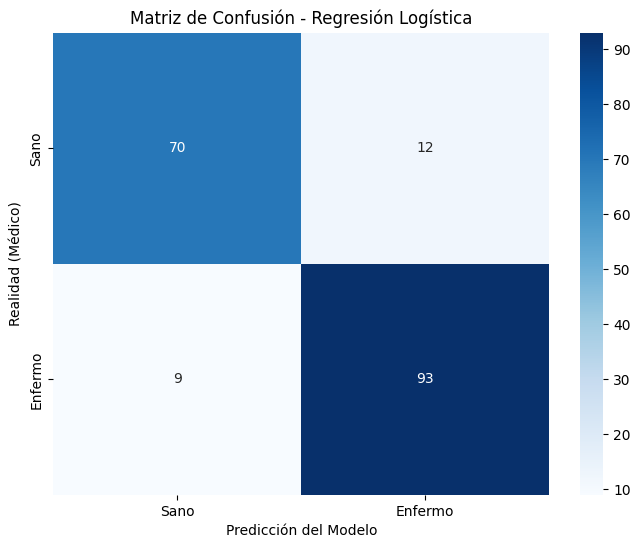

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Creamos la matriz comparando la realidad (y_test) con la predicción (y_pred_test)
cm = confusion_matrix(y_test, y_predic_test)

# 2. La dibujamos para que sea fácil de leer
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sano', 'Enfermo'], 
            yticklabels=['Sano', 'Enfermo'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Médico)')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

Mi modelo de momento parece robusto tiene un 3% de diferencia de Acuaricy no tiene overfiting y no da 9 FALSOS NEGATIVOS y 12 FALSOS POSITIVOS. 

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 1. Probabilidades para el ROC-AUC de la Regresión Logística
y_probs_log_test = modelo_log.predict_proba(X_test_scaled)[:, 1]

# 2. Cálculo de métricas
precision_log = precision_score(y_test, y_predic_test) # y_pred_test eran las de logística
recall_log = recall_score(y_test, y_predic_test)
f1_log = f1_score(y_test, y_predic_test)
roc_auc_log = roc_auc_score(y_test, y_probs_log_test)

print("Métricas Regresión Logística:")
print(f"Precision: {precision_log:.4f}")
print(f"Recall: {recall_log:.4f}")
print(f"F1-Score: {f1_log:.4f}")
print(f"ROC-AUC: {roc_auc_log:.4f}")

Métricas Regresión Logística:
Precision: 0.8857
Recall: 0.9118
F1-Score: 0.8986
ROC-AUC: 0.9254


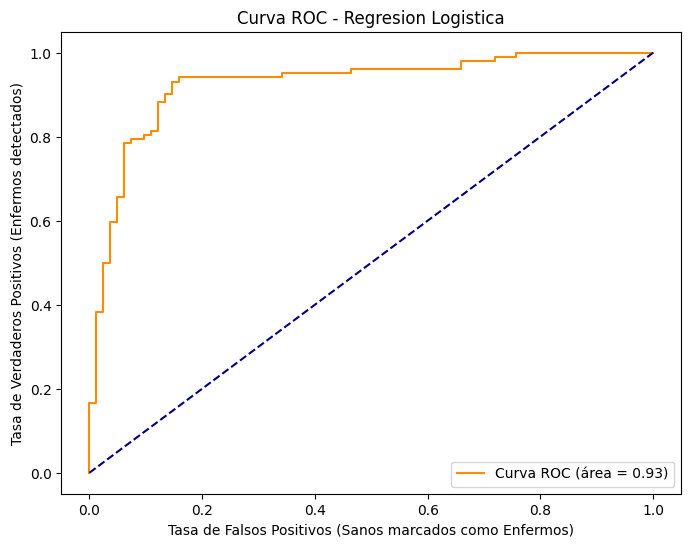

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculamos la curva
fpr, tpr, thresholds = roc_curve(y_test, y_probs_log_test)
roc_auc = auc(fpr, tpr)

# 2. La dibujamos
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'Curva ROC (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Línea de suerte
plt.xlabel('Tasa de Falsos Positivos (Sanos marcados como Enfermos)')
plt.ylabel('Tasa de Verdaderos Positivos (Enfermos detectados)')
plt.title('Curva ROC - Regresion Logistica')
plt.legend(loc="lower right")
plt.show()

HACEMOS VALIDACION CRUZADA PARA REGRECION LOGISTICA

In [23]:
from sklearn.model_selection import cross_val_score

# 1. Definimos X_scaled para todo el dataset porque antes solo hemos hecho .fit en el X_train no en X_test ahora tenemos que hacerlo en todo 
# Usamos el objeto 'scaler' que ya habías ajustado antes
X_scaled = scaler.transform(X)

# 1. Ejecutamos la validación cruzada para el ROC-AUC
# Usamos X_scaled para que la logística funcione correctamente
cv_scores_log = cross_val_score(modelo_log, X_scaled, y, cv=5, scoring='roc_auc')

print(f"Resultados de los 5 Folds: {cv_scores_log}")
print(f"Media ROC-AUC: {cv_scores_log.mean():.4f}")
print(f"Desviación Estándar: {cv_scores_log.std():.4f}")

Resultados de los 5 Folds: [0.95396939 0.94595887 0.91128647 0.90376721 0.84267085]
Media ROC-AUC: 0.9115
Desviación Estándar: 0.0395


La curva roc no ha variado casi nada 0.93 a 0.91 entonces antes nuestro modelo aprendio bien y predijo bien

In [14]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

# Entrenamos el modelo
# Voy a usar X_train_scaled porque lo escale pero en realidad este algoritmo no necesita escalado podria usar X_train
modelo_rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
# Realizar predicciones
y_pred_rf_train = modelo_rf.predict(X_train_scaled)
y_pred_rf_test = modelo_rf.predict(X_test_scaled)

# Calculamos el acuaricy
acc_rf_train = accuracy_score(y_train, y_pred_rf_train)
acc_rf_test = accuracy_score(y_test, y_pred_rf_test)

print(f"RF - Accuracy Entrenamiento: {acc_rf_train:.4f}")
print(f"RF - Accuracy Prueba: {acc_rf_test:.4f}")
diferencia_rf = abs(acc_rf_train - acc_rf_test)
print(f"Diferencia: {diferencia_rf:.4f}")

RF - Accuracy Entrenamiento: 0.9986
RF - Accuracy Prueba: 0.8098
Diferencia: 0.1889


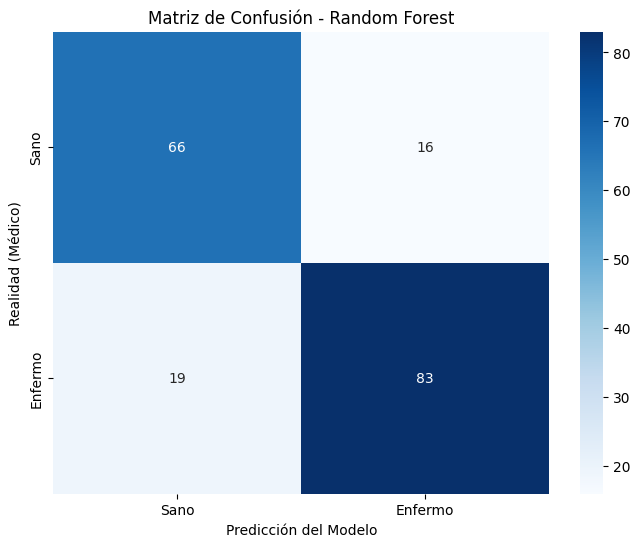

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Creamos la matriz comparando la realidad (y_test) con la predicción (y_pred_test)
cm_rf = confusion_matrix(y_test, y_pred_rf_test)

# 2. La dibujamos para que sea fácil de leer
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sano', 'Enfermo'], 
            yticklabels=['Sano', 'Enfermo'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Médico)')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 1. Calculamos las probabilidades para el ROC-AUC (importante usar X_test_scaled)
y_probs_rf_test = modelo_rf.predict_proba(X_test_scaled)[:, 1]

# 2. Calculamos el bloque de métricas
precision = precision_score(y_test, y_pred_rf_test)
recall = recall_score(y_test, y_pred_rf_test)
f1 = f1_score(y_test, y_pred_rf_test)
roc_auc = roc_auc_score(y_test, y_probs_rf_test)

print(f"Métricas Random Forest (Sin ajustar):")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Métricas Random Forest (Sin ajustar):
Precision: 0.8384
Recall: 0.8137
F1-Score: 0.8259
ROC-AUC: 0.8853


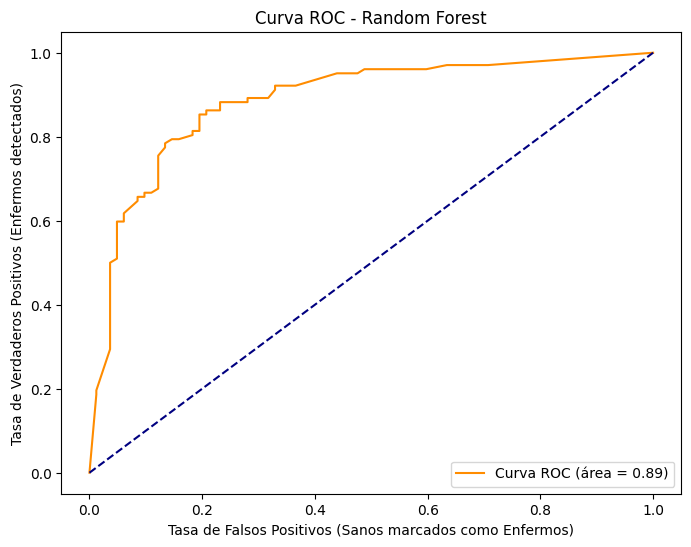

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculamos la curva
fpr, tpr, thresholds = roc_curve(y_test, y_probs_rf_test)
roc_auc = auc(fpr, tpr)

# 2. La dibujamos
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'Curva ROC (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Línea de suerte
plt.xlabel('Tasa de Falsos Positivos (Sanos marcados como Enfermos)')
plt.ylabel('Tasa de Verdaderos Positivos (Enfermos detectados)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.show()

HACEMOS VALIDACION CRUZADA PARA RANDOM FOREST